# Chagas Detection using a convolutional neural network approach

### Import libraries and create data directory

In [1]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torch.utils.data import WeightedRandomSampler

from torchvision.datasets import CIFAR10
from torchvision.transforms import ToTensor
from torchvision.utils import make_grid
from torchvision import transforms
import torchvision.transforms.functional as F 

import lightning as L
from lightning.pytorch import seed_everything
from lightning.pytorch.callbacks.early_stopping import EarlyStopping

import torchmetrics as TM

from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os
import h5py

In [2]:
def create_data_directory(path: str):
    if not os.path.exists(path):
        os.makedirs(path)

dir_dataroot = os.path.join("..", "data")
create_data_directory(dir_dataroot)

dir_lightning = os.path.join("..", "lightning")
create_data_directory(dir_lightning)

SEED = 123456

## SaMi-Trop

### Loading the SaMi-Trop dataset

In [3]:
sami_labels = pd.read_csv("data/samitrop_chagas_labels.csv")
sami_data = pd.read_csv("data/sami_trop.csv")
print(sami_labels.shape)
print(sami_data.shape)

(815, 2)
(1631, 7)


Number of positive cases: 815
Number of negative cases: 816


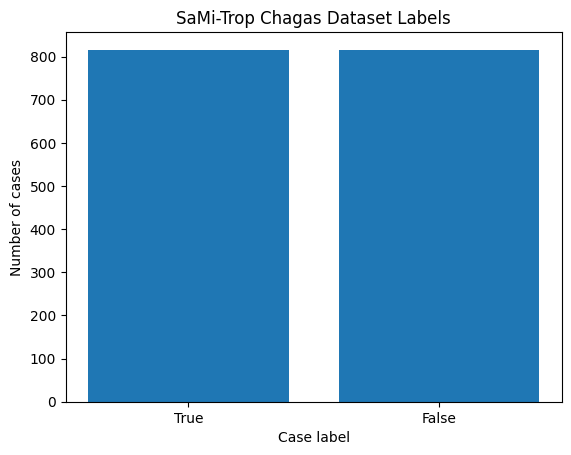

In [4]:
print(f"Number of positive cases: {len(sami_labels)}")
print(f"Number of negative cases: {len(sami_data)-len(sami_labels)}")
labels = ["True", "False"]
num_labels = [len(sami_labels), (len(sami_data)-len(sami_labels))]
plt.bar(labels, num_labels)
plt.title("SaMi-Trop Chagas Dataset Labels")
plt.ylabel("Number of cases")
plt.xlabel("Case label")
plt.show()

### Formatting data

In [5]:
# File permissions must be changed to allow the file to be read
!chmod 644 "data/exams.hdf5"

In [6]:
# Reading the SaMi-Trop hdf5 data
f = h5py.File('data/exams.hdf5', 'r')

st_dset = f['tracings']
st_dset.shape

(1631, 4096, 12)

In [7]:
num_exam_ids = len(st_dset)
print(f"Number of exams: {num_exam_ids}")
exam_id_list = sami_data['exam_id']
# List of exam ids that have a positive Chagas label
pos_chagas_exams = sami_labels['exam_id'].tolist()
print(f"Number of exam IDs: {len(exam_id_list)}")

Number of exams: 1631
Number of exam IDs: 1631


In [8]:
# Creating a list containing the target labels for SaMi-Trop
st_targets = []
for i in range(len(st_dset)):
    print(i)
    
    patient_exam = st_dset[i].transpose()
    exam_id = exam_id_list[i]
    print(exam_id)
    if exam_id in pos_chagas_exams:
        chagas_label = 1
    else:
        chagas_label = 0
    print(chagas_label)
    st_targets.append(chagas_label)

0
294669
0
1
291318
0
2
247007
1
3
181629
1
4
250434
0
5
253698
0
6
253958
0
7
406936
1
8
250492
0
9
253803
1
10
253036
0
11
253214
1
12
239656
1
13
239746
0
14
248457
1
15
250438
0
16
253738
0
17
286703
0
18
291321
0
19
307960
0
20
285515
1
21
262072
1
22
262071
0
23
262070
0
24
254020
0
25
254029
0
26
254026
1
27
23710
1
28
278468
1
29
267640
0
30
245807
0
31
245805
0
32
246063
1
33
246014
0
34
267643
0
35
267575
0
36
267585
0
37
278507
0
38
267529
1
39
253942
0
40
267645
1
41
267525
0
42
255774
1
43
255702
0
44
255764
0
45
278635
0
46
218745
0
47
255674
0
48
70829
0
49
247004
0
50
222354
0
51
222359
1
52
222356
0
53
222349
1
54
222362
0
55
437329
1
56
248627
1
57
248626
0
58
248634
1
59
248629
0
60
248628
0
61
222350
0
62
248637
1
63
217447
1
64
217448
1
65
214334
1
66
214348
1
67
254022
0
68
267374
1
69
254024
1
70
254025
0
71
254031
1
72
254023
1
73
254019
1
74
255672
0
75
267377
1
76
277210
1
77
262069
1
78
218263
0
79
218288
0
80
218217
1
81
218139
0
82
218093
0
83
217881
0
84
2

In [9]:
# Transforming the HDF5 Dataset object into a numpy array and transposing it
numpyarr = np.array(st_dset)
# Convert the array to float32 
numpyarr = numpyarr.astype(np.float32)
# Transpose from (1631, 4096, 12) to (1631, 12, 4096)
# This is more intuitive for reading each of the 12 exams
numpyarr = np.transpose(numpyarr, (0,2,1))
print(numpyarr.shape)
print(numpyarr.dtype)

(1631, 12, 4096)
float32


## Code-15%

### Loading the Code-15% Dataset

In [10]:
# File permissions must be changed to allow the file to be read
!chmod 644 "data/exams_part1.hdf5"

In [11]:
# Reading CODE-15% (part 1) hdf5 data
f = h5py.File('data/exams_part1.hdf5', 'r')

c15_dset = f['tracings']
c15_exam_id_list = f['exam_id']
print(c15_dset.shape)
print(c15_exam_id_list.shape)

(20001, 4096, 12)
(20001,)


In [12]:
code15_labels = pd.read_csv("data/code15_chagas_labels.csv")
code15_labels.shape

(343424, 3)

In [14]:
c15_targets = []
for i in range(len(c15_dset)):
    print(i)
    patient_exam = c15_dset[i]
    exam_id = c15_exam_id_list[i]
    print(f"Exam id: {exam_id}")
    row = code15_labels[code15_labels['exam_id'] == exam_id]["exam_id"]
    if (row.index.size == 0):
        chagas_label = 0
        print("Exam missing from chagas labels file, assumed to be False")
    else:
        print(f"Row index: {row.index[0]}")
        chagas_label = code15_labels.loc[row.index[0],"chagas"]
        if (chagas_label):
            chagas_label = 1
        else:
            chagas_label = 0
    
    print(chagas_label)
    c15_targets.append(chagas_label)

0
Exam id: 4409337
Row index: 36451
0
1
Exam id: 835969
Row index: 247710
0
2
Exam id: 2540049
Row index: 88038
0
3
Exam id: 3123252
Row index: 209904
0
4
Exam id: 1658846
Row index: 122312
0
5
Exam id: 1602958
Row index: 340556
0
6
Exam id: 2762516
Row index: 229428
0
7
Exam id: 767032
Row index: 49515
0
8
Exam id: 3141625
Row index: 110735
0
9
Exam id: 596124
Row index: 259115
0
10
Exam id: 1353716
Row index: 40230
0
11
Exam id: 2672494
Row index: 215253
0
12
Exam id: 2668899
Row index: 285736
0
13
Exam id: 884099
Row index: 332511
0
14
Exam id: 526403
Row index: 136931
0
15
Exam id: 1325550
Row index: 132351
0
16
Exam id: 2675631
Row index: 130819
0
17
Exam id: 3005973
Row index: 316396
0
18
Exam id: 380160
Row index: 252624
0
19
Exam id: 3117757
Row index: 213817
0
20
Exam id: 3204821
Row index: 247062
0
21
Exam id: 1372286
Row index: 227654
0
22
Exam id: 1359082
Row index: 107667
0
23
Exam id: 2524265
Row index: 260073
0
24
Exam id: 2943367
Row index: 238287
0
25
Exam id: 2985547


In [15]:
# Transforming the HDF5 Dataset object into a numpy array and transposing it
code15arr = np.array(c15_dset)
code15arr = code15arr.astype(np.float32)
# Transpose from (1631, 4096, 12) to (1631, 12, 4096)
# This is more intuitive for reading each of the 12 exams
code15arr = np.transpose(code15arr, (0,2,1))
print(code15arr.shape)
print(code15arr.dtype)

(20001, 12, 4096)
float32


### Neural Network functions

In [16]:
# Define a class to hold the ECG dataset information
# In this class, I paired all 12 leads of a patient's ECG
# with the True/False Chagas label
class ECGDataSet(torch.utils.data.Dataset):
    def __init__(self, ECGleads, labels):
        self.ECGleads = ECGleads
        self.labels = labels
    
    def __len__(self):
        return len(self.ECGleads)
    
    def __getitem__(self, index):
        if isinstance(index, slice):
            return [self.__getitem__(i) for i in range(*index.indices(len(self)))]
        else:
            return self.ECGleads[index], self.labels[index]

In [17]:
# Make encoder
class ECGEncoder(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=2, stride=2, padding=0):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, out_channels, kernel_size=kernel_size, stride=stride, padding=padding),  # conv1d layer 
            nn.MaxPool1d(kernel_size=2, stride=2),                 # max pooling layer with kernel size 2x2        
            nn.ReLU()                                             # ReLU activation function
        )

    def forward(self, x):
        x = self.encoder(x)
        return x

# Test the IECGEncoder with random input data
encoder = ECGEncoder(12, 32) # 12 = input channels, 32 = number of output channels
input_ecg = torch.randn(1, 12, 4096)  # batch_size x channels x sequence length
output_features = encoder(input_ecg)
print("Output shape:", output_features.shape)

Output shape: torch.Size([1, 32, 1024])


In [18]:
# Decoder
class ECGDecoder(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.flatten = nn.Flatten()  # Flatten the input tensor
        self.linear = nn.Linear(input_dim,1)  # Linear layer with 1 output unit
        
    def forward(self, x):
        x = self.flatten(x)  # Flatten the input tensor
        x = self.linear(x)   # Pass through the linear layer
        return x.view(-1, 1).squeeze(1)

# Test the ECGDecoder module with random input data
decoder = ECGDecoder(1*32*1024, 2)
input_tensor = torch.randn(1, 32, 1024)  # Batch size of 1, input tensor shape [1, 32, 1024]
rslt = decoder(input_tensor)
print("Rslt shape:", rslt.shape)  # Expected output shape: [1]
print(rslt.dtype)

Rslt shape: torch.Size([1])
torch.float32


In [19]:
# Classifier 
# ==========================================================================================
# For future neural networks, the main thing that will change is the encoder and the decoder
# ==========================================================================================
class ECGClassifier(L.LightningModule):
    def __init__(self, encoder, decoder, num_classes):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        
       # validation metrics - we will use these to compute the metrics at the end of the validation epoch
        self.validation_step_outputs = []
        self.validation_step_targets = []

        # test metrics - we will use these to compute the metrics at the end of the test epoch
        self.test_roc = TM.ROC(task="binary") # roc and cm have methods we want to call so store them in a variable
        self.test_cm = TM.ConfusionMatrix(task="binary")
        self.test_metrics_tracker = TM.wrappers.MetricTracker(TM.MetricCollection([ 
                                                           self.test_roc, self.test_cm])) 
        
        # test outputs and targets - we will store the outputs and targets for the test step
        self.test_step_outputs = []
        self.test_step_targets = []

    # the forward method applies the encoder and decoder to the input
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

    # the training step. pass the batch through the model and compute the loss
    def training_step(self, batch, batch_idx):
        x, y = batch
        
        # Creating scale for the labels
        scale = 1-(torch.sum(y)/len(y))
        # Creating weights for the positive class (positive for Chagas)
        pos_weights = y*scale
        pos_weights = torch.where(pos_weights<scale, 1-scale, pos_weights)
        
        logits = self.forward(x)
        # Here we pass the weights for the positive class to the loss function
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y.float(), pos_weights)
        self.log('train_loss', loss)
        return loss
    
    # the validation step. pass the batch through the model and compute the loss. Store the outputs and targets for the epoch end step and log the loss
    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y.float())
        self.log('val_loss', loss, on_step=True, on_epoch=True)
        
        # store the outputs and targets for the epoch end step
        self.validation_step_outputs.append(logits)
        self.validation_step_targets.append(y)
        return loss
    
    # the test step. pass the batch through the model and compute the loss. Store the outputs and targets for the epoch end step and log the loss
    def test_step(self, batch, batch_idx):
        x, y = batch
        logits = self.forward(x)
        loss = nn.functional.binary_cross_entropy_with_logits(logits, y.float())
        self.log('test_loss', loss, on_step=True, on_epoch=True)
        self.test_step_outputs.append(logits)
        self.test_step_targets.append(y)
        return loss
    
    # at the end of the epoch compute the metrics
    def on_validation_epoch_end(self):
        # -------------------------------------------------------------------------------
        # This runs after each epoch and calculates the metrics for the validation tests.
        # -------------------------------------------------------------------------------
        # stack all the outputs and targets into a single tensor
        all_preds = torch.hstack(self.validation_step_outputs)
        all_targets = torch.hstack(self.validation_step_targets)
        
        print(all_preds.shape)
        print(all_targets.shape)
        # compute the metrics
        loss = nn.functional.binary_cross_entropy_with_logits(all_preds, all_targets.float())
        self.log('val_loss_epoch_end', loss)
        
        # clear the validation step outputs
        self.validation_step_outputs.clear()
        self.validation_step_targets.clear()
    
    def on_test_epoch_end(self):
        # -----------------------------------------------------------------------
        # This runs after each epoch and calculates the metrics for the test set.
        # -----------------------------------------------------------------------
        all_preds = torch.hstack(self.test_step_outputs)
        all_targets = torch.hstack(self.test_step_targets)
        
        self.test_metrics_tracker.increment()
        self.test_metrics_tracker.update(all_preds, all_targets)
        # clear the test step outputs
        self.test_step_outputs.clear()
        self.test_step_targets.clear()

    def configure_optimizers(self):
        # ------------------------------------------------------------------------------------------------------
        # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # ------------------------------------------------------------------------------------------------------
        # This part of the function automatically updates the weights for your model and moves to the next batch
        # If you do this WITHOUT the lightning module, you will need to do this yourself.
        # ------------------------------------------------------------------------------------------------------
        # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        # ------------------------------------------------------------------------------------------------------
        optimizer = optim.Adam(self.parameters(), lr=1e-3)
        return optimizer

### Combining data from SaMi-Trop & Code-15%

In [20]:
# Combining numpy arrays for the data
print(f"CODE-15% data: {code15arr.shape}")
print(f"SaMi-Trop data: {numpyarr.shape}")
concat_arr = np.concatenate((code15arr, numpyarr), axis=0)
print(f"Total data: {concat_arr.shape}")

CODE-15% data: (20001, 12, 4096)
SaMi-Trop data: (1631, 12, 4096)
Total data: (21632, 12, 4096)


In [21]:
print(f"Number of CODE-15% labels: {len(c15_targets)}")
print(f"Number of SaMi-Trop labels: {len(st_targets)}")
concat_targets = c15_targets + st_targets
print(f"Total number of labels: {len(concat_targets)}")

Number of CODE-15% labels: 20001
Number of SaMi-Trop labels: 1631
Total number of labels: 21632


In [23]:
# Creating instance of customer Dataset object with ECG exams and Chagas labels
concat_ds = ECGDataSet(concat_arr, concat_targets)

# Splitting the data into training, validation, and test subsets
concat_train, concat_val, concat_test = torch.utils.data.random_split(concat_ds, [0.7,0.2,0.1])

#### Figuring out class weights for addressing imbalance
I originally set out to use a WeightedRandomSampler for addressing class imbalance, but instead I ended up adding a weights variable to the loss function during the training step of the neural network. This code is just to show my process and it can be helpful to see the distributions for the training, validation, and test subsets. 

In [24]:
# Collecting a list of the labels in each of the subsets
train_labels = []
val_labels = []
test_labels = []
for i in concat_train:
    train_labels.append(i[1])
for i in concat_val:
    val_labels.append(i[1])
for i in concat_test:
    test_labels.append(i[1])

# Printing out the class weights
print(f"====================================")
print(f"*** Class weights by data subset ***")
print(f"====================================")
print(f"TRAINING... Positive: {train_labels.count(1)}, Negative: {train_labels.count(0)}, Percent: {train_labels.count(1)/train_labels.count(0):.5f}")    
print(f"VALIDATION... Positive: {val_labels.count(1)}, Negative: {val_labels.count(0)}, Percent: {val_labels.count(1)/val_labels.count(0):.5f}")    
print(f"TESTING... Positive: {test_labels.count(1)}, Negative: {test_labels.count(0)}, Percent: {test_labels.count(1)/test_labels.count(0):.5f}")

*** Class weights by data subset ***
TRAINING... Positive: 872, Negative: 14271, Percent: 0.06110
VALIDATION... Positive: 234, Negative: 4092, Percent: 0.05718
TESTING... Positive: 126, Negative: 2037, Percent: 0.06186


In [25]:
def getSampler(labels): 
    pos = labels.count(1)
    neg = labels.count(0)
    pos_weight = 1/pos
    neg_weight = 1/neg
    print(f"{pos_weight}, {neg_weight}")
    # Need tensor of length 'labels' that contains the positive and negative weights
    sampler = WeightedRandomSampler(weights=[pos_weight, neg_weight], num_samples=len(labels), replacement=True)
    return sampler

## Training the CNN

In [26]:
# Creating dataloaders for each of the subsets
batch_size = 100
train_loader = DataLoader(concat_train, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(concat_val, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(concat_test, batch_size=batch_size, shuffle=False)

In [28]:
# Creating instances of the encoder, decoder, and classifier classes
encoder = ECGEncoder(12, 32)
decoder = ECGDecoder(1*32*1024, 2)
model = ECGClassifier(encoder, decoder, 2)

# Training the model using Pytorch Lightning
trainer = L.Trainer(default_root_dir=dir_lightning, 
                    max_epochs=20,
                    callbacks=[EarlyStopping(monitor="val_loss_epoch_end", mode="min", patience=3)],)
trainer.fit(model=model, train_dataloaders=train_loader, val_dataloaders=val_loader)

/home/jmaench/.conda/envs/cpsc4300torch/lib/python3.10/site-packages/torchmetrics/utilities/prints.py:43: FutureWarning: The default value for `maximize` will be changed from `True` to `None` in v1.7.0 of TorchMetrics,will automatically infer the value based on the `higher_is_better` attribute of the metric (if such attribute exists) or raise an error if it does not. If you are explicitly setting the `maximize` argument to either `True` or `False` already, you can ignore this warning.
  warnings.warn(*args, **kwargs)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/jmaench/.conda/envs/cpsc4300torch/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use 

Sanity Checking DataLoader 0: 100%|██████████| 2/2 [00:00<00:00,  9.60it/s]torch.Size([200])
torch.Size([200])
Epoch 0:   0%|          | 0/152 [00:00<?, ?it/s]                           positive weights --> tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.9000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.9000, 0.9000,
        0.9000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.9000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.9000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.9000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.9000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.9000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.9000, 0.1000, 0

In [29]:
# Running the model on the test subset
trainer.test(model=model, dataloaders=test_loader)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Testing DataLoader 0: 100%|██████████| 22/22 [00:00<00:00, 34.45it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│      test_loss_epoch      │    0.5392429232597351     │
└───────────────────────────┴───────────────────────────┘

[{'test_loss_epoch': 0.5392429232597351}]

In [30]:
# Gathering the metrics from the test subset
rslt = model.test_metrics_tracker.compute()

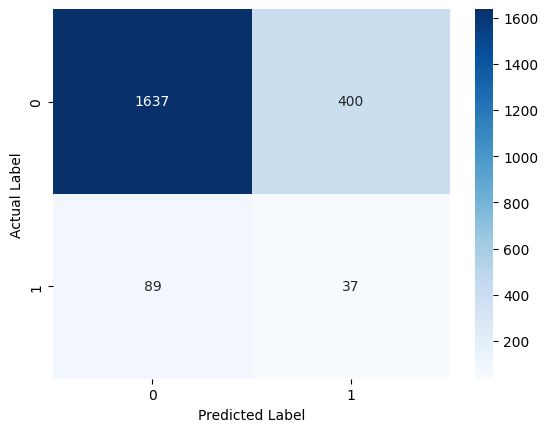

In [31]:
# Plotting the confusion matrix
cmp = sns.heatmap(rslt['BinaryConfusionMatrix'], annot=True, fmt='d', cmap='Blues')
cmp.set_xlabel('Predicted Label')
cmp.set_ylabel('Actual Label');

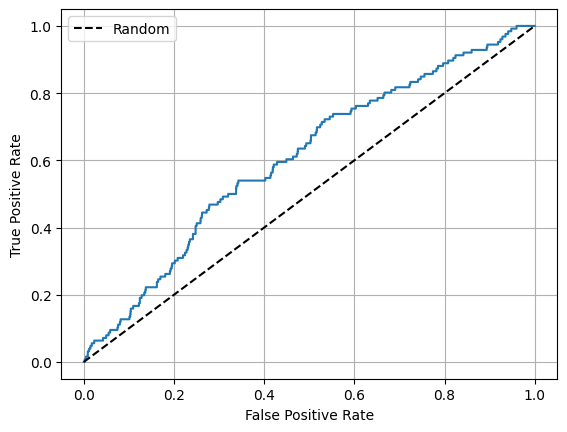

In [32]:
# Plotting the ROC curve
fpr, tpr, thresholds = rslt['BinaryROC']
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid()

In [33]:
# Gathering and printing out the classification report
device = torch.device("cpu")   #"cuda:0"
# put the model in evaluation mode so that the parameters are fixed and we don't compute gradients
model.eval()
y_true=[]
y_pred=[]
# use torch.no_grad() to disable gradient computation
with torch.no_grad():
    # iterate over the test loader minibatches
    for test_data in test_loader:
        # get the images and labels from the test loader and move them to the cpu. this will make it easier to use them with sklearn
        # print(test_data)
        test_ecgs, test_labels = test_data[0].to(device), test_data[1].to(device)
        sig = nn.Sigmoid()
        pred = sig(model(test_ecgs))
        threshold = 0.5
        pred = pred > threshold
        for i in range(len(pred)):
            y_true.append(test_labels[i].item())
            y_pred.append(pred[i].item())

print(classification_report(y_true,y_pred,target_names=["negative", "positive"],digits=4))

              precision    recall  f1-score   support

    negative     0.9484    0.8036    0.8701      2037
    positive     0.0847    0.2937    0.1314       126

    accuracy                         0.7739      2163
   macro avg     0.5166    0.5486    0.5007      2163
weighted avg     0.8981    0.7739    0.8270      2163

